In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl
from scipy.integrate import solve_ivp
# import sympy as sp
import os

mpl.rc('figure', figsize=(12, 6))
mpl.rc('text', usetex = False)
mpl.rc('font', family = 'serif')
mpl.rc('font', size = '14')
mpl.rc('xtick', labelsize=14) 
mpl.rc('ytick', labelsize=14)
mpl.rcParams['mathtext.fontset'] = 'stix'


import matplotlib.pyplot as plt

plt.rcParams['mathtext.fontset'] = 'stix'
plt.rcParams['font.family'] = 'serif'

#colors = ['#3C536D', '#DAC746', '#3390D7', '#DC4D57', '#237b68', '#B0705F']
import matplotlib as mpl

# Use a serif font for all text
mpl.rcParams['font.family'] = 'serif'
mpl.rcParams['font.size'] = 12  # Set global font size
mpl.rcParams['mathtext.fontset'] = 'stix'  # Use Times-compatible math fonts
mpl.rcParams['axes.titlesize'] = 16  # Larger title font
mpl.rcParams['axes.labelsize'] = 14  # Larger axis label font

In [2]:
# Armemos un código para graficar las perturbaciones
def pert(t, y, k, g_mplm2):
    phi, phi_dot, dphi_k, dphi_dot_k, chi_k, chi_dot_k = y

    # Ecuación para φ
    phi_ddot = - phi
    
    # Ecuaciones para δφ_k
    dphi_ddot_k = - (k**2 + 1) * dphi_k
    
    # Ecuaciones para χ_k
    # chi_ddot_k = -3 * H * chi_dot_k - (k**2 / a**2 + g_mplm2 * phi**2) * chi_k
    chi_ddot_k = - (k**2 + g_mplm2 * phi**2) * chi_k
    
    return [phi_dot, phi_ddot, dphi_dot_k, dphi_ddot_k, chi_dot_k, chi_ddot_k]

In [3]:
q = 2e2
Ak = 2*q+1

#g = 1e-1
#mpl_m = 1e6 #m_pl / m

k = np.sqrt(Ak - 2 * q ) 
g_mplm2 = q**2 #( g * mpl_m )**2

# print(f'Ak = {Ak}')
# print(f'q = {q}')

In [4]:
# Rango de tiempo de integración
nf = 15
t0, tf = 0, nf * np.pi
t_eval = np.linspace(t0, tf, int(1e4))

# Condiciones iniciales
# Background
phi0 = 1#1/np.sqrt(np.pi)
phiprime0 = phi0

# Perturbaciones
# Omega_phi = k**2 + 3 * phi0**2
# Omega_chi = k**2 + g**2 * phi0**2
dphi_k0 = 0#1/np.sqrt(2 * Omega_phi)
dphi_dot_k0 = 0#1/np.sqrt(2 * Omega_phi)
chi_k0 = 0#1/np.sqrt(2 * Omega_chi)
chi_dot_k0 = 1#1/np.sqrt(2 * Omega_chi)#0

y0 = [phi0, phiprime0, dphi_k0, dphi_dot_k0, chi_k0, chi_dot_k0]

In [5]:
# Resolvamos el sistema acoplado
sol = solve_ivp(pert, [t0, tf], y0, args=(k, g_mplm2), t_eval=t_eval, method = "Radau", rtol=1e-8, atol=1e-8)

In [6]:
# Extraemos los resultados
t_sol = sol.t
phi_sol = sol.y[0]

# dphi_sol = sol.y[2]
chi_sol = sol.y[4]
chidot_sol = sol.y[5]

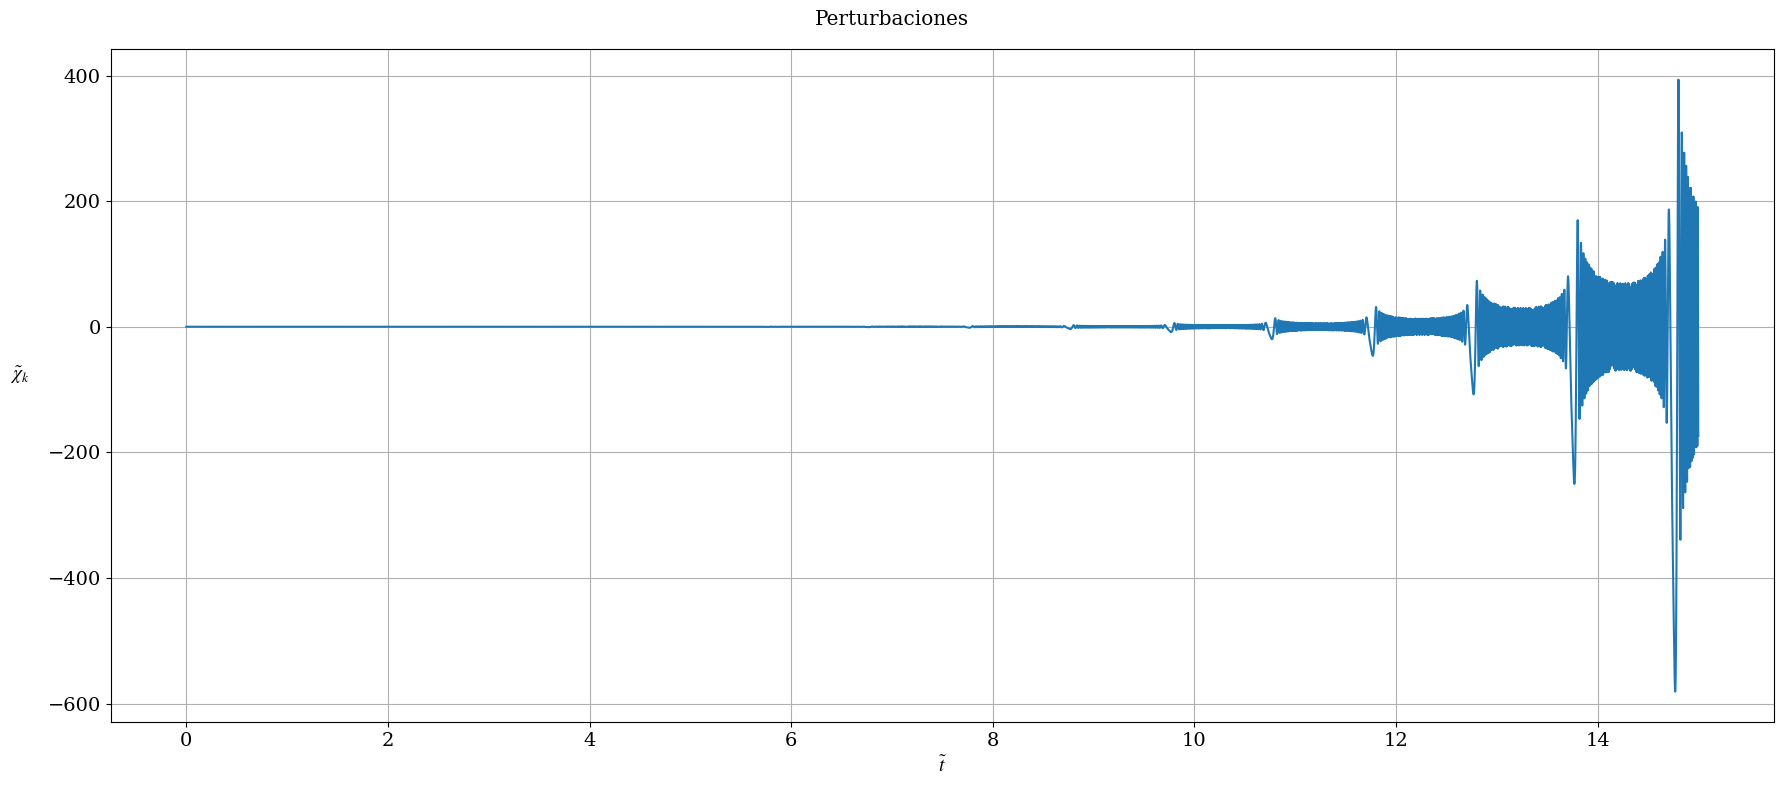

In [7]:
plt.figure(figsize = (18, 8))

# plt.subplot(1,2,1)
# plt.plot(sol.t, dphi_sol)
# plt.ylabel(r"$\delta \tilde{\phi}_k$", labelpad = 20, rotation = "horizontal")
# plt.xlabel(r"$\tilde{t}$")
# plt.grid()

# plt.subplot(1,2,2)
plt.plot(sol.t/np.pi, chi_sol)
plt.ylabel(r"$\tilde{\chi}_k$", labelpad = 20, rotation = "horizontal")
plt.xlabel(r"$\tilde{t}$")
plt.grid()

plt.suptitle("Perturbaciones")
plt.tight_layout()
plt.show()

In [8]:
omega_k = np.sqrt( k**2 + g_mplm2 * phi_sol**2 )

nk = omega_k / 2 * ( np.abs(chidot_sol)**2 / omega_k**2 + np.abs(chi_sol)**2 )

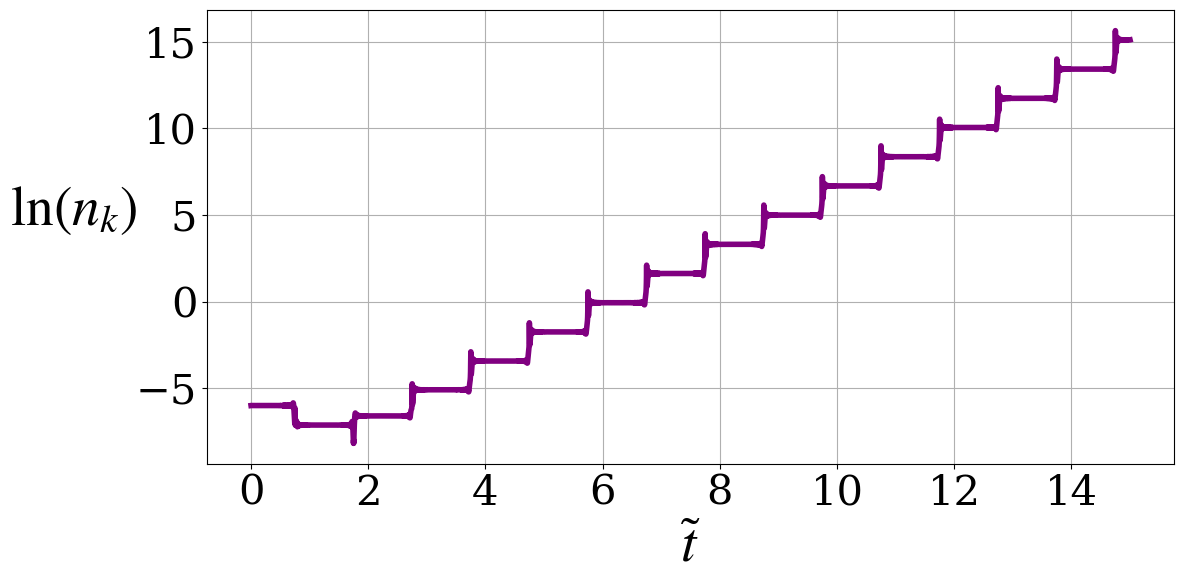

In [9]:
plt.figure(figsize = (12, 6))

plt.plot(sol.t/np.pi, np.log(nk), lw = 4, color = "purple")
plt.ylabel(r"$\ln(n_k)$", labelpad = 45, rotation = "horizontal", fontsize = 40)
plt.xlabel(r"$\tilde{t}$", fontsize = 40)
plt.grid()
plt.xticks(fontsize = 30)
plt.yticks(fontsize = 30)
plt.tight_layout()
#plt.show()

plt.savefig("nk_Broad_Resonance_m2phi2.pdf", format = "pdf")

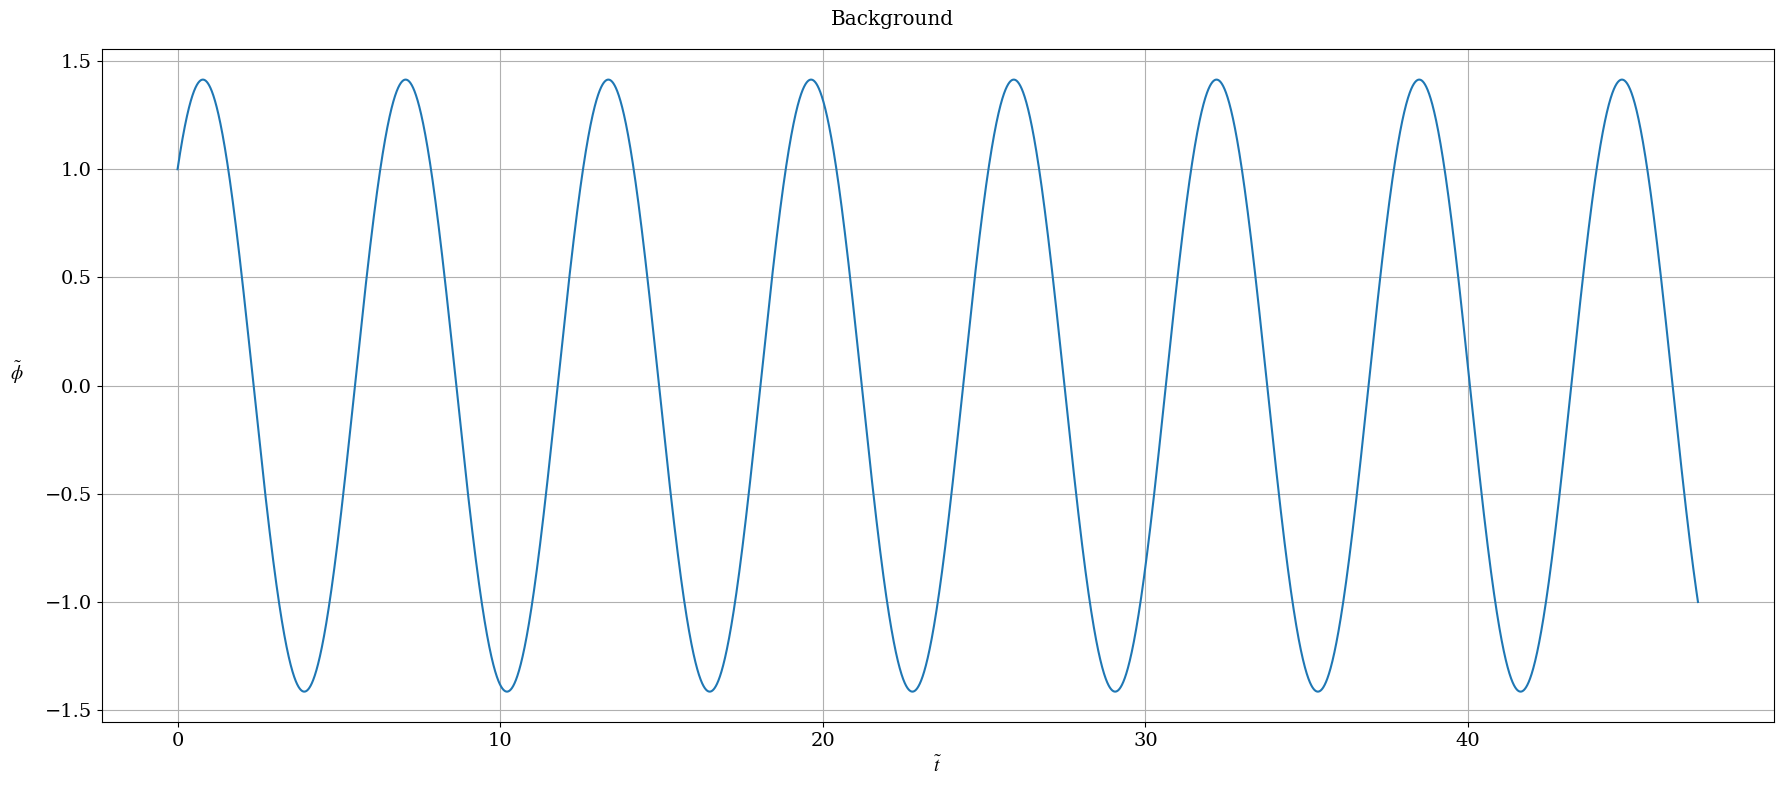

In [10]:
plt.figure(figsize = (18, 8))

plt.plot(sol.t, phi_sol)
plt.ylabel(r"$\tilde{\phi}$", labelpad = 20, rotation = "horizontal")
plt.xlabel(r"$\tilde{t}$")
plt.grid()

plt.suptitle("Background")
plt.tight_layout()
plt.show()

In [11]:
q = 1e-1
Ak = 2*q+1.01

#g = 1e-1
#mpl_m = 1e6 #m_pl / m

k = np.sqrt(Ak - 2 * q ) 
g_mplm2 = q**2 #( g * mpl_m )**2

# print(f'Ak = {Ak}')
# print(f'q = {q}')

In [12]:
# Rango de tiempo de integración
nf = 15
t0, tf = 0, nf * np.pi
t_eval = np.linspace(t0, tf, int(1e4))

# Condiciones iniciales
# Background
phi0 = 1#1/np.sqrt(np.pi)
phiprime0 = phi0

# Perturbaciones
# Omega_phi = k**2 + 3 * phi0**2
# Omega_chi = k**2 + g**2 * phi0**2
dphi_k0 = 0#1/np.sqrt(2 * Omega_phi)
dphi_dot_k0 = 0#1/np.sqrt(2 * Omega_phi)
chi_k0 = 0#1/np.sqrt(2 * Omega_chi)
chi_dot_k0 = 1#1/np.sqrt(2 * Omega_chi)#0

y0 = [phi0, phiprime0, dphi_k0, dphi_dot_k0, chi_k0, chi_dot_k0]

In [13]:
# Resolvamos el sistema acoplado
sol = solve_ivp(pert, [t0, tf], y0, args=(k, g_mplm2), t_eval=t_eval, method = "Radau", rtol=1e-8, atol=1e-8)

In [14]:
# Extraemos los resultados
t_sol = sol.t
phi_sol = sol.y[0]

# dphi_sol = sol.y[2]
chi_sol = sol.y[4]
chidot_sol = sol.y[5]

In [15]:
omega_k = np.sqrt( k**2 + g_mplm2 * phi_sol**2 )

nk = omega_k / 2 * ( np.abs(chidot_sol)**2 / omega_k**2 + np.abs(chi_sol)**2 )

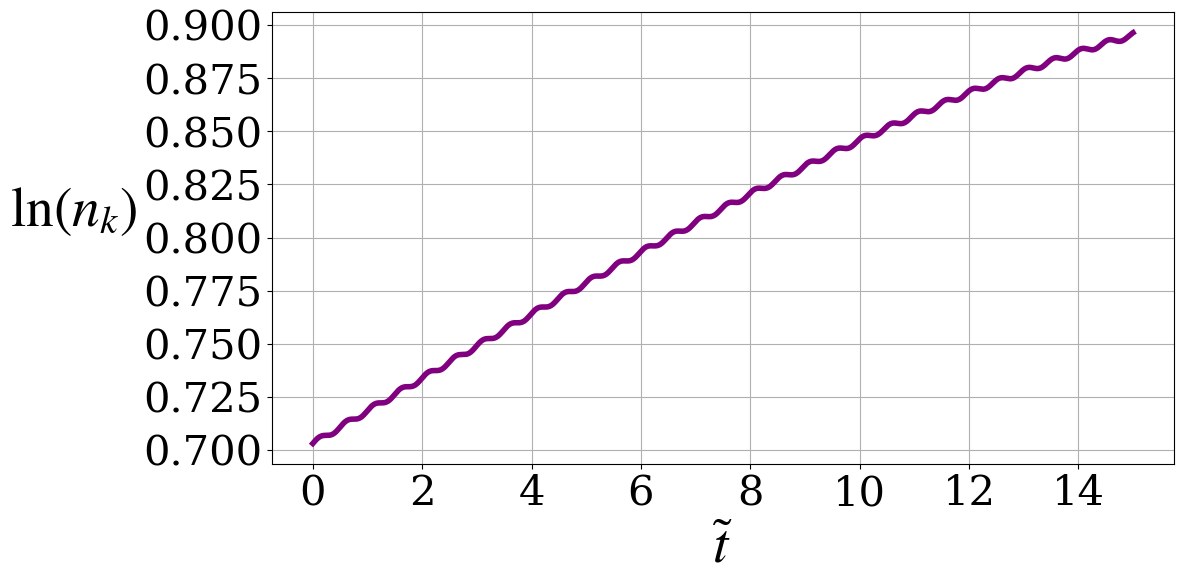

In [16]:
plt.figure(figsize = (12, 6))

plt.plot(sol.t/np.pi, np.abs(np.log(nk)), lw = 4, color = "purple")
plt.ylabel(r"$\ln(n_k)$", labelpad = 50, rotation = "horizontal", fontsize = 40)
plt.xlabel(r"$\tilde{t}$", fontsize = 40)
plt.grid()
plt.xticks(fontsize = 30)
plt.yticks(fontsize = 30)
plt.tight_layout()
#plt.show()

plt.savefig("nk_Narrow_Resonance_m2phi2.pdf", format = "pdf")